In [ ]:
from src.find_bids.models.extract.dataset import Dataset
from src.find_bids.models.extract.series import SeriesFeatures
# from src.find_bids.models.infer.core import infer_bids_datatype

from pathlib import Path
import sqlite3

import seaborn as sns
import pandas as pd
from rich.progress import track
from wordcloud import WordCloud
from matplotlib import pyplot as plt

In [2]:
features_root_dirs = [
    Path("/Volumes/csi/Quarles_Lab/find_BIDS/features/PROACTIVE"),
    Path("/Volumes/csi/Quarles_Lab/find_BIDS/features/QIAC")
]

column_names: list[str] = ["subject_id", "session_id", "n_series"]
rows = []

for features_root_dir in features_root_dirs:
    dataset: Dataset = Dataset.from_json(features_root_dir / "dataset.json")
    for subject in dataset.subjects or []:
        for session in subject.sessions or []:
            n_series = len(session.series) if session.series is not None else 0
            rows.append({
                "subject_id": subject.subject_id,
                "session_id": session.session_id,
                "n_series": n_series
            })
            
df = pd.DataFrame(rows, columns=column_names)


In [3]:
df.head()

,subject_id,session_id,n_series
0,2379-7808,2379-7808-2384-8383,16
1,2379-7808,2379-7808-3495-3045,24
2,2379-7808,2379-7808-3535-7796,28
3,2379-7808,2379-7808-2395-0318,24
4,2379-7808,2379-7808-3577-9779,15


Text(0, 0.5, 'Count of Sessions')

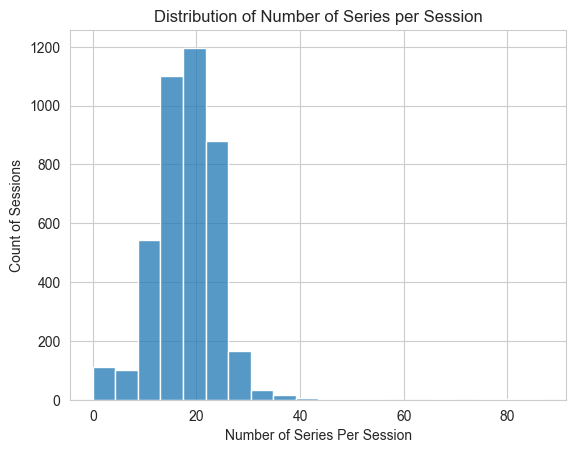

In [4]:
sns.set_style("whitegrid")
ax = sns.histplot(data=df, x="n_series", bins=20, kde=False)
ax.set_title("Distribution of Number of Series per Session")
ax.set_xlabel("Number of Series Per Session")
ax.set_ylabel("Count of Sessions")

In [5]:
median_n_series = df["n_series"].median()
mean_n_series = df["n_series"].mean()
print(f"Mean number of series per session: {mean_n_series}")
std_n_series = df["n_series"].std()
print(f"Median number of series per session: {median_n_series}")
print(f"Standard deviation of number of series per session: {std_n_series}")
# Total number of series
total_series = df["n_series"].sum()
print(f"Total number of series: {total_series}")
# Total number of sessions
total_sessions = len(df)
print(f"Total number of sessions: {total_sessions}")

Mean number of series per session: 18.202068799615105
Median number of series per session: 18.0
Standard deviation of number of series per session: 6.186161210454608
Total number of series: 75666
Total number of sessions: 4157


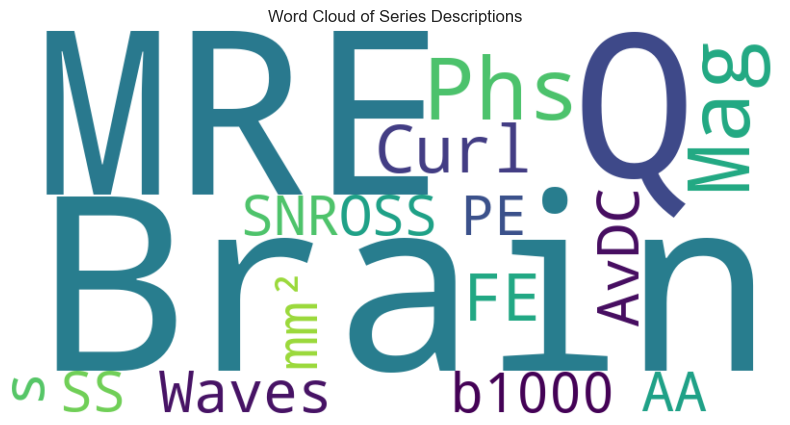

In [6]:
series_descriptions = ["FE Curl Waves: Brain MRE :-Q", "AvDC (10^-6 mm²/s): b1000", "PE Phs and Mag: Brain MRE :-Q", "AA OSS SNR: Brain MRE", "SS Phs and Mag: Brain MRE :-Q"]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(series_descriptions))
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Series Descriptions")
plt.show()

In [7]:
db_path = Path("/Volumes/csi/Quarles_Lab/find_BIDS/features/features.db")
db_conn = sqlite3.connect(db_path)
all_series = SeriesFeatures.from_sqlite_all(db_conn)

Loaded 75571 series feature entries from the database


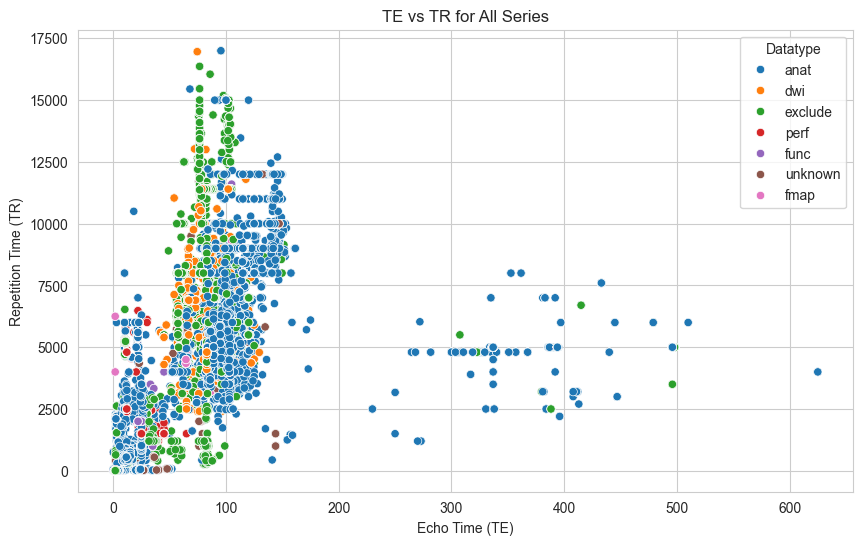

In [14]:
# Get all TE,TR values and plot them
te_tr_values = []
inferred_datatypes = []
for series_features in all_series:
    te = series_features.temporal.echo_time.value if series_features.temporal else None
    tr = series_features.temporal.repetition_time.value if series_features.temporal else None
    inferred_datatype = infer_bids_datatype(series_features)
    inferred_datatypes.append(inferred_datatype)
    te_tr_values.append((te, tr))
        
# Plot TE vs TR with datatypes colored differently
te_tr_df = pd.DataFrame(te_tr_values, columns=["TE", "TR"])
te_tr_df["Datatype"] = inferred_datatypes
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=te_tr_df, x="TE", y="TR", hue="Datatype")
plt.title("TE vs TR for All Series")
plt.xlabel("Echo Time (TE)")
plt.ylabel("Repetition Time (TR)")
plt.show()